# Part 2: Bias Audit — Who Does the Model Hurt?

**Objective:** Systematically measure whether the baseline classifier treats comments associated with Black identity differently from those associated with White identity across multiple fairness metrics.

This notebook:
1. Constructs demographic cohorts from the evaluation set
2. Computes TPR, FPR, FNR, Precision, and Disparate Impact per cohort
3. Uses `aif360` to compute Statistical Parity Difference and Equal Opportunity Difference
4. Produces grouped bar charts and per-cohort confusion matrices

In [2]:
# !pip install aif360 fairlearn transformers torch scikit-learn matplotlib seaborn --quiet
!pip install aif360

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 1.9 MB/s eta 0:00:00a 0:00:01


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

SEED = 42
np.random.seed(SEED)
THRESHOLD = 0.4  # chosen in Part 1
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2.1 Load Evaluation Data & Model Predictions

In [5]:
# Load the evaluation set with predictions saved in Part 1
df_eval = pd.read_csv('/kaggle/input/datasets/i222058hamzamahmood/eval-with-preds/eval_with_preds.csv')
print(f"Evaluation set shape: {df_eval.shape}")
print(f"Columns: {list(df_eval.columns)}")
df_eval.head(3)

Evaluation set shape: (20000, 10)
Columns: ['comment_text', 'toxic', 'black', 'homosexual_gay_or_lesbian', 'jewish', 'muslim', 'white', 'label', 'y_proba', 'y_pred_04']


,comment_text,toxic,black,homosexual_gay_or_lesbian,jewish,muslim,white,label,y_proba,y_pred_04
0,"In Sitka, and other SE communities there is in...",0.0,NaN,NaN,NaN,NaN,NaN,0,0.000479,0
1,Trump lies an average of 7 times a day and the...,0.6,NaN,NaN,NaN,NaN,NaN,1,0.001322,0
2,"Sure. When someone breaks into my home, I'll j...",0.0,NaN,NaN,NaN,NaN,NaN,0,0.001080,0


In [6]:
# If y_proba is not already present, recompute from saved model
if 'y_proba' not in df_eval.columns:
    print("Recomputing predictions from saved model...")
    tokenizer = AutoTokenizer.from_pretrained('/kaggle/input/datasets/i222058hamzamahmood/model-baseline')
    model = AutoModelForSequenceClassification.from_pretrained('/kaggle/input/datasets/i222058hamzamahmood/model-baseline')
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    all_probs = []
    batch_size = 64
    texts = df_eval['comment_text'].tolist()

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True, max_length=128, return_tensors='pt').to(device)
        with torch.no_grad():
            logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)

    df_eval['y_proba'] = all_probs

df_eval['y_pred'] = (df_eval['y_proba'] >= THRESHOLD).astype(int)
print(f"Predictions ready. Threshold = {THRESHOLD}")

Predictions ready. Threshold = 0.4


## 2.2 Construct Demographic Cohorts

In [18]:
# Fill NaN identity columns with 0 (no annotation = not associated)
for col in ['black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian']:
    if col in df_eval.columns:
        df_eval[col] = df_eval[col].fillna(0.0)

# High-black cohort: black >= 0.5
df_black = df_eval[df_eval['black'] >= 0.5].copy()

# Reference cohort: black < 0.1 AND white >= 0.5
df_white = df_eval[(df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)].copy()

print("=" * 50)
print(f"HIGH-BLACK COHORT size:  {len(df_black):,} rows")
print(f"REFERENCE COHORT size:   {len(df_white):,} rows")
print("=" * 50)
print(f"\nHigh-black toxic rate:  {df_black['label'].mean():.4f}")
print(f"Reference toxic rate:   {df_white['label'].mean():.4f}")

HIGH-BLACK COHORT size:  164 rows
REFERENCE COHORT size:   196 rows

High-black toxic rate:  0.2744
Reference toxic rate:   0.2704


## 2.3 Fairness Metrics per Cohort

In [19]:
def compute_cohort_metrics(df, cohort_name):
    y_true = df['label'].values
    y_pred = df['y_pred'].values

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # Recall = Sensitivity
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # Fall-out
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # Miss rate
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0  # Precision
    pos_pred_rate = y_pred.mean()  # For Disparate Impact

    return {
        'Cohort': cohort_name, 'N': len(df),
        'TPR': round(tpr, 4), 'FPR': round(fpr, 4),
        'FNR': round(fnr, 4), 'Precision': round(prec, 4),
        'Pos Pred Rate': round(pos_pred_rate, 4),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

metrics_black = compute_cohort_metrics(df_black, 'High-Black')
metrics_white = compute_cohort_metrics(df_white, 'Reference (White)')

# Disparate Impact: FPR(black) / FPR(reference)
disparate_impact = metrics_black['FPR'] / metrics_white['FPR'] if metrics_white['FPR'] > 0 else float('inf')

summary = pd.DataFrame([metrics_black, metrics_white])
display_cols = ['Cohort', 'N', 'TPR', 'FPR', 'FNR', 'Precision', 'Pos Pred Rate']
print("=" * 70)
print("FAIRNESS AUDIT SUMMARY")
print("=" * 70)
print(summary[display_cols].to_string(index=False))
print(f"\nDisparate Impact (FPR ratio, Black/Reference): {disparate_impact:.4f}")
print("  -> Ratio > 1.0 suggests higher over-flagging in High-Black; confirm with uncertainty estimates.")

FAIRNESS AUDIT SUMMARY
           Cohort   N    TPR    FPR    FNR  Precision  Pos Pred Rate
       High-Black 164 0.6000 0.1429 0.4000     0.6136         0.2683
Reference (White) 196 0.6226 0.1259 0.3774     0.6471         0.2602

Disparate Impact (FPR ratio, Black/Reference): 1.1350
  -> Ratio > 1.0 suggests higher over-flagging in High-Black; confirm with uncertainty estimates.


## 2.4 AIF360 Metrics: Statistical Parity & Equal Opportunity

In [20]:
# Construct AIF360-compatible datasets
# We need a combined dataframe with a 'protected_attribute' column
df_combined = pd.concat([
    df_black.assign(group=0),   # unprivileged: black cohort
    df_white.assign(group=1),   # privileged: white reference
], ignore_index=True)

# Ground truth AIF360 dataset
aif_true = BinaryLabelDataset(
    df=df_combined[['label', 'group']].rename(columns={'label': 'label_col'}),
    label_names=['label_col'],
    protected_attribute_names=['group'],
    favorable_label=0,    # non-toxic = favorable (not flagged)
    unfavorable_label=1
)

# Predicted AIF360 dataset
aif_pred = aif_true.copy()
aif_pred.labels = df_combined['y_pred'].values.reshape(-1, 1)

# Classification metric
cm_metric = ClassificationMetric(
    aif_true, aif_pred,
    unprivileged_groups=[{'group': 0}],
    privileged_groups=[{'group': 1}]
)

spd = cm_metric.statistical_parity_difference()
eod = cm_metric.equal_opportunity_difference()

print("=" * 50)
print("AIF360 FAIRNESS METRICS")
print("=" * 50)
print(f"Statistical Parity Difference:  {spd:.4f}")
print("  (ideal = 0.0; negative = High-Black has lower favorable prediction rate)")
print(f"Equal Opportunity Difference:   {eod:.4f}")
print("  (with favorable_label=0, negative means lower TPR for non-toxic comments)")

AIF360 FAIRNESS METRICS
Statistical Parity Difference:  -0.0081
  (ideal = 0.0; negative = High-Black has lower favorable prediction rate)
Equal Opportunity Difference:   -0.0170
  (with favorable_label=0, negative means lower TPR for non-toxic comments)


## 2.5 Visualizations

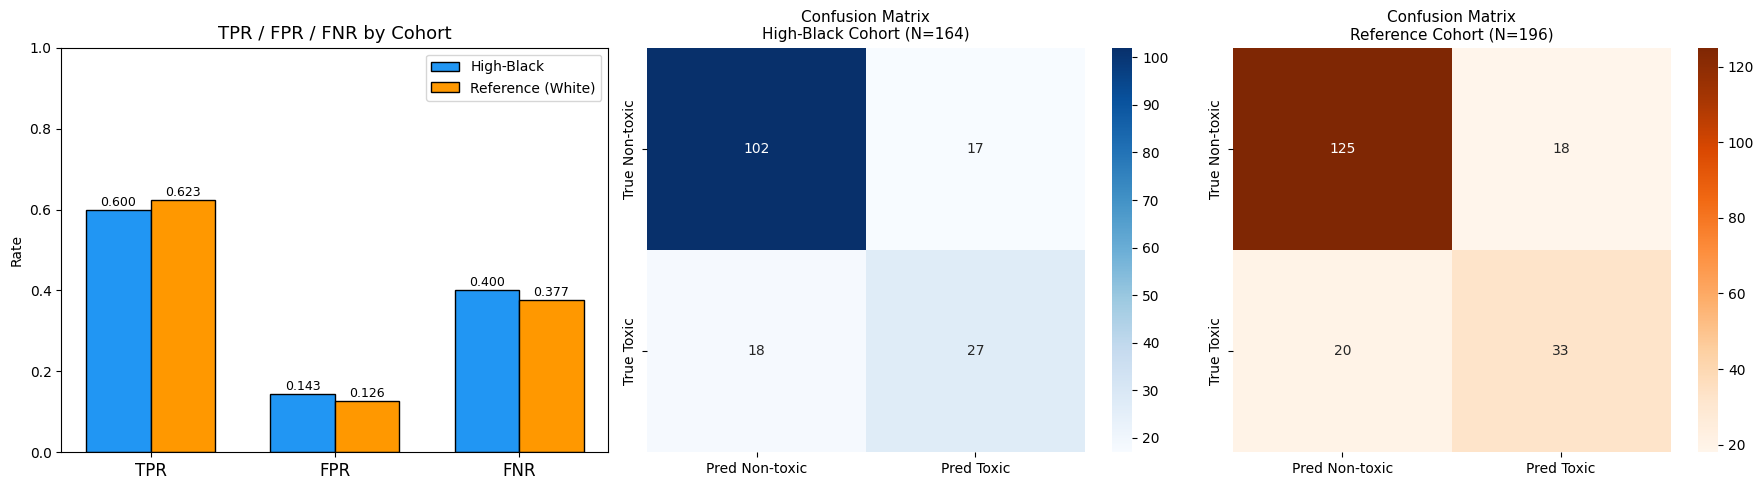

Saved part2_bias_audit.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Grouped Bar Chart: TPR, FPR, FNR ---
metrics_labels = ['TPR', 'FPR', 'FNR']
black_vals  = [metrics_black['TPR'],  metrics_black['FPR'],  metrics_black['FNR']]
white_vals  = [metrics_white['TPR'],  metrics_white['FPR'],  metrics_white['FNR']]

x = np.arange(len(metrics_labels))
width = 0.35
bars1 = axes[0].bar(x - width/2, black_vals, width, label='High-Black', color='#2196F3', edgecolor='black')
bars2 = axes[0].bar(x + width/2, white_vals, width, label='Reference (White)', color='#FF9800', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_labels, fontsize=12)
axes[0].set_ylabel('Rate'); axes[0].set_title('TPR / FPR / FNR by Cohort', fontsize=13)
axes[0].legend(); axes[0].set_ylim(0, 1)
for bar in bars1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)

# --- Confusion Matrix: High-Black ---
cm_b = confusion_matrix(df_black['label'], df_black['y_pred'], labels=[0,1])
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred Non-toxic','Pred Toxic'],
            yticklabels=['True Non-toxic','True Toxic'])
axes[1].set_title(f'Confusion Matrix\nHigh-Black Cohort (N={len(df_black)})', fontsize=11)

# --- Confusion Matrix: Reference ---
cm_w = confusion_matrix(df_white['label'], df_white['y_pred'], labels=[0,1])
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Pred Non-toxic','Pred Toxic'],
            yticklabels=['True Non-toxic','True Toxic'])
axes[2].set_title(f'Confusion Matrix\nReference Cohort (N={len(df_white)})', fontsize=11)

plt.tight_layout()
plt.savefig('part2_bias_audit.png', dpi=150)
plt.show()
print("Saved part2_bias_audit.png")

In [22]:
# Full summary table
print("\n" + "=" * 70)
print("COMPLETE BIAS AUDIT SUMMARY TABLE")
print("=" * 70)
full_summary = pd.DataFrame([
    {
        'Metric': 'Cohort Size', 'High-Black': metrics_black['N'], 'Reference': metrics_white['N']
    },
    {'Metric': 'Toxic Base Rate',
     'High-Black': f"{df_black['label'].mean():.4f}",
     'Reference': f"{df_white['label'].mean():.4f}"},
    {'Metric': 'TPR (Recall)', 'High-Black': metrics_black['TPR'], 'Reference': metrics_white['TPR']},
    {'Metric': 'FPR (Fall-out)', 'High-Black': metrics_black['FPR'], 'Reference': metrics_white['FPR']},
    {'Metric': 'FNR (Miss Rate)', 'High-Black': metrics_black['FNR'], 'Reference': metrics_white['FNR']},
    {'Metric': 'Precision', 'High-Black': metrics_black['Precision'], 'Reference': metrics_white['Precision']},
    {'Metric': 'Disparate Impact (FPR ratio)', 'High-Black': f"{disparate_impact:.4f}", 'Reference': '1.0 (baseline)'},
    {'Metric': 'Statistical Parity Difference', 'High-Black': f"{spd:.4f}", 'Reference': '—'},
    {'Metric': 'Equal Opportunity Difference', 'High-Black': f"{eod:.4f}", 'Reference': '—'},
])
print(full_summary.to_string(index=False))


COMPLETE BIAS AUDIT SUMMARY TABLE
                       Metric High-Black      Reference
                  Cohort Size        164            196
              Toxic Base Rate     0.2744         0.2704
                 TPR (Recall)        0.6         0.6226
               FPR (Fall-out)     0.1429         0.1259
              FNR (Miss Rate)        0.4         0.3774
                    Precision     0.6136         0.6471
 Disparate Impact (FPR ratio)     1.1350 1.0 (baseline)
Statistical Parity Difference    -0.0081              —
 Equal Opportunity Difference    -0.0170              —


## 2.6 Analysis: Which Metric Shows the Largest Disparity?

### Key Findings

The model shows a **mild disparity pattern** against the High-Black cohort. The clearest policy-relevant signal is a higher **False Positive Rate (FPR)** for High-Black (0.1429) than Reference (0.1259), which corresponds to an FPR ratio of 1.1350. This suggests more over-flagging of non-toxic comments in the High-Black cohort.

### Why this should be interpreted cautiously

The subgroup sizes are small (High-Black: 164, Reference: 196), so metric estimates can vary noticeably. The observed gaps are directionally consistent with bias concerns, but they are not large enough to claim strong statistical significance without uncertainty checks (for example, bootstrap confidence intervals).

### Error Direction and Practical Impact

| Error Type | Affected Group | Real-World Consequence |
|---|---|---|
| **Higher FPR** (over-flagging) | High-Black | More non-toxic comments from this cohort are incorrectly flagged, which can suppress legitimate speech and increase moderation burden. |
| **Higher FNR** (under-flagging) | Any | More toxic content is missed, reducing user protection and trust in moderation quality. |

### Conclusion

This audit provides **preliminary evidence** of over-flagging for the High-Black cohort, but the effect size appears modest in this sample. A responsible next step is to quantify uncertainty and then apply mitigation methods in Part 4 aimed at reducing cohort FPR gaps while preserving overall recall.